# USD/LKR Exchange Rate Forecasting

## Model Development and Forecasting

This stage develops and evaluates multiple forecasting approaches for the USD/LKR exchange-rate series.

The modelling stage uses the feature-engineered dataset produced in the previous stage.

The models will be evaluated using time-based validation to preserve the chronological structure of the exchange-rate data.

The following modelling approaches will be considered:

- Naive Forecast
- ARIMA
- GARCH
- XGBoost
- LSTM

Model performance will be compared using appropriate forecasting evaluation metrics.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

## 2. Load the Feature-Engineered Dataset

The feature-engineered dataset generated in the previous stage is loaded for model development.

The dataset contains the original USD/LKR exchange-rate series together with lagged, return-based, and rolling statistical features.

In [9]:
df = pd.read_csv(
    "../data/processed/feature_engineered_dataset.csv"
)

In [10]:
df.head()

,date,USD_LKR,log_return,rolling_volatility_20,Lag_1,Lag_5,Lag_20,Return_Lag_1,Return_Lag_5,Return_Lag_20,Rolling_Mean_5,Rolling_Mean_20,Rolling_Std_20,Target
0,2010-10-13,111.9335,-0.003326,0.001652,112.3064,112.6897,113.6292,-0.002115,0.000745,-0.000601,112.38808,113.041855,0.602375,111.5154
1,2010-11-09,111.5154,-0.003742,0.001753,111.9335,112.6132,113.6854,-0.003326,-0.000679,0.000494,112.16852,112.933355,0.671790,111.5843
2,2010-11-10,111.5843,0.000618,0.001772,111.5154,112.5431,113.7009,-0.003742,-0.000623,0.000136,111.97676,112.827525,0.710135,111.6845
3,2010-11-11,111.6845,0.000898,0.001816,111.5843,112.5442,113.6573,0.000618,0.000010,-0.000384,111.80482,112.728885,0.725655,111.6000
4,2010-11-12,111.6000,-0.000757,0.001729,111.6845,112.3064,113.8271,0.000898,-0.002115,0.001493,111.66354,112.617530,0.719109,111.6850


In [11]:
df.shape

(3477, 14)

## 3. Inspect the Dataset Structure

The available variables are examined before modelling to confirm that the required predictors and forecasting target are present.

In [12]:
df.columns

Index(['date', 'USD_LKR', 'log_return', 'rolling_volatility_20', 'Lag_1',
       'Lag_5', 'Lag_20', 'Return_Lag_1', 'Return_Lag_5', 'Return_Lag_20',
       'Rolling_Mean_5', 'Rolling_Mean_20', 'Rolling_Std_20', 'Target'],
      dtype='str')

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3477 entries, 0 to 3476
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   3477 non-null   str    
 1   USD_LKR                3477 non-null   float64
 2   log_return             3477 non-null   float64
 3   rolling_volatility_20  3477 non-null   float64
 4   Lag_1                  3477 non-null   float64
 5   Lag_5                  3477 non-null   float64
 6   Lag_20                 3477 non-null   float64
 7   Return_Lag_1           3477 non-null   float64
 8   Return_Lag_5           3477 non-null   float64
 9   Return_Lag_20          3477 non-null   float64
 10  Rolling_Mean_5         3477 non-null   float64
 11  Rolling_Mean_20        3477 non-null   float64
 12  Rolling_Std_20         3477 non-null   float64
 13  Target                 3477 non-null   float64
dtypes: float64(13), str(1)
memory usage: 380.4 KB


## 4. Check Missing Values

Before model development, the feature-engineered dataset is checked for missing observations.

Any remaining incomplete observations must be handled before fitting the forecasting models.

In [14]:
df.isna().sum()

date                     0
USD_LKR                  0
log_return               0
rolling_volatility_20    0
Lag_1                    0
Lag_5                    0
Lag_20                   0
Return_Lag_1             0
Return_Lag_5             0
Return_Lag_20            0
Rolling_Mean_5           0
Rolling_Mean_20          0
Rolling_Std_20           0
Target                   0
dtype: int64

In [25]:
df_model = df.dropna().copy()

In [26]:
df_model.isna().sum()

date                     0
USD_LKR                  0
log_return               0
rolling_volatility_20    0
Lag_1                    0
Lag_5                    0
Lag_20                   0
Return_Lag_1             0
Return_Lag_5             0
Return_Lag_20            0
Rolling_Mean_5           0
Rolling_Mean_20          0
Rolling_Std_20           0
Target                   0
dtype: int64

## 5. Verify the Modelling Dataset

The cleaned modelling dataset is inspected to confirm its dimensions and ensure that all observations required for model development are available.

The dataset is also checked to confirm that the observations remain in chronological order.

In [28]:
print("Original dataset shape:", df.shape)
print("Modelling dataset shape:", df_model.shape)

print("\nMissing values after cleaning:")
print(df_model.isna().sum().sum())

print("\nDates are sorted:")
print(df_model["date"].is_monotonic_increasing)

Original dataset shape: (3477, 14)
Modelling dataset shape: (3477, 14)

Missing values after cleaning:
0

Dates are sorted:
True


## 6. Prepare the Date Variable

The date variable is converted to datetime format and the dataset is sorted chronologically.

Maintaining the correct temporal order is essential because the project is a time-series forecasting problem.

In [29]:
df_model["date"] = pd.to_datetime(df_model["date"])

df_model = df_model.sort_values(
    "date"
).reset_index(drop=True)

print("First observation:", df_model["date"].min())
print("Last observation:", df_model["date"].max())

First observation: 2010-10-13 00:00:00
Last observation: 2026-09-24 00:00:00


## 7. Inspect the Modelling Dataset

The final modelling dataset is inspected before splitting the observations into training and testing periods.

The dataset contains the original USD/LKR exchange rate, return-based features, lagged variables, rolling statistics, and the one-step-ahead forecasting target.

In [30]:
df_model.head()

,date,USD_LKR,log_return,rolling_volatility_20,Lag_1,Lag_5,Lag_20,Return_Lag_1,Return_Lag_5,Return_Lag_20,Rolling_Mean_5,Rolling_Mean_20,Rolling_Std_20,Target
0,2010-10-13,111.9335,-0.003326,0.001652,112.3064,112.6897,113.6292,-0.002115,0.000745,-0.000601,112.38808,113.041855,0.602375,111.5154
1,2010-11-09,111.5154,-0.003742,0.001753,111.9335,112.6132,113.6854,-0.003326,-0.000679,0.000494,112.16852,112.933355,0.671790,111.5843
2,2010-11-10,111.5843,0.000618,0.001772,111.5154,112.5431,113.7009,-0.003742,-0.000623,0.000136,111.97676,112.827525,0.710135,111.6845
3,2010-11-11,111.6845,0.000898,0.001816,111.5843,112.5442,113.6573,0.000618,0.000010,-0.000384,111.80482,112.728885,0.725655,111.6000
4,2010-11-12,111.6000,-0.000757,0.001729,111.6845,112.3064,113.8271,0.000898,-0.002115,0.001493,111.66354,112.617530,0.719109,111.6850


In [31]:
df_model.tail()

,date,USD_LKR,log_return,rolling_volatility_20,Lag_1,Lag_5,Lag_20,Return_Lag_1,Return_Lag_5,Return_Lag_20,Rolling_Mean_5,Rolling_Mean_20,Rolling_Std_20,Target
3472,2026-09-18,332.1338,0.000728,0.001951,331.8920,328.5966,331.8318,0.005183,-0.000470,-0.001368,330.38242,329.197710,1.268419,330.3490
3473,2026-09-21,330.3490,-0.005388,0.002268,332.1338,328.6751,331.2303,0.000728,0.000239,-0.001814,330.71720,329.153645,1.207957,330.8125
3474,2026-09-22,330.8125,0.001402,0.002171,330.3490,329.0351,330.1657,-0.005388,0.001095,-0.003219,331.07268,329.185985,1.244582,329.8867
3475,2026-09-23,329.8867,-0.002802,0.002209,330.8125,330.1761,329.4456,0.001402,0.003462,-0.002183,331.01480,329.208040,1.253302,329.0158
3476,2026-09-24,329.0158,-0.002643,0.002271,329.8867,331.8920,329.0037,-0.002802,0.005183,-0.001342,330.43956,329.208645,1.253201,330.3522


In [32]:
print("Number of observations:", len(df_model))
print("Number of variables:", len(df_model.columns))

Number of observations: 3477
Number of variables: 14


In [33]:
df_model.columns.tolist()

['date',
 'USD_LKR',
 'log_return',
 'rolling_volatility_20',
 'Lag_1',
 'Lag_5',
 'Lag_20',
 'Return_Lag_1',
 'Return_Lag_5',
 'Return_Lag_20',
 'Rolling_Mean_5',
 'Rolling_Mean_20',
 'Rolling_Std_20',
 'Target']

## 8. Time-Based Train-Test Split

The modelling dataset is divided chronologically into training and testing periods.

An 80% training and 20% testing split is used.

The earlier observations are used to train the forecasting models, while the most recent observations are reserved for evaluating their forecasting performance.

A random train-test split is not used because it could allow future observations to influence the training process and cause data leakage.

In [34]:
split_index = int(len(df_model) * 0.80)

train = df_model.iloc[:split_index].copy()
test = df_model.iloc[split_index:].copy()

print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train["date"].min(), "to", train["date"].max())

print("\nTesting period:")
print(test["date"].min(), "to", test["date"].max())

Training observations: 2781
Testing observations: 696

Training period:
2010-10-13 00:00:00 to 2023-11-06 00:00:00

Testing period:
2023-11-07 00:00:00 to 2026-09-24 00:00:00


## 9. Visualize the Training and Testing Periods

The chronological train-test split is visualized to confirm that the training observations precede the testing observations.

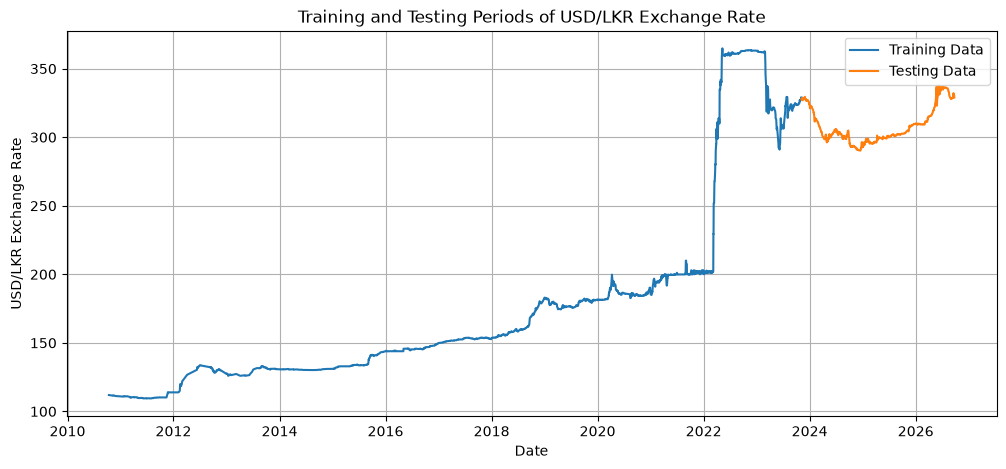

In [35]:
plt.figure(figsize=(12, 5))

plt.plot(
    train["date"],
    train["USD_LKR"],
    label="Training Data"
)

plt.plot(
    test["date"],
    test["USD_LKR"],
    label="Testing Data"
)

plt.title("Training and Testing Periods of USD/LKR Exchange Rate")
plt.xlabel("Date")
plt.ylabel("USD/LKR Exchange Rate")
plt.legend()
plt.grid(True)

plt.show()

## 10. Define Predictor Variables

The predictor variables are selected from the feature-engineered dataset.

These variables represent historical information available at time t and are therefore suitable for one-step-ahead forecasting.

In [36]:
feature_columns = [
    "USD_LKR",
    "log_return",
    "rolling_volatility_20",
    "Lag_1",
    "Lag_5",
    "Lag_20",
    "Return_Lag_1",
    "Return_Lag_5",
    "Return_Lag_20",
    "Rolling_Mean_5",
    "Rolling_Mean_20",
    "Rolling_Std_20"
]

In [37]:
print("Number of predictor variables:", len(feature_columns))

print("\nPredictor variables:")
for feature in feature_columns:
    print("-", feature)

Number of predictor variables: 12

Predictor variables:
- USD_LKR
- log_return
- rolling_volatility_20
- Lag_1
- Lag_5
- Lag_20
- Return_Lag_1
- Return_Lag_5
- Return_Lag_20
- Rolling_Mean_5
- Rolling_Mean_20
- Rolling_Std_20


## 11. Define Predictors and Forecasting Target

The forecasting problem is formulated as a one-step-ahead prediction problem.

For each observation at time t, the model uses information available at time t to predict the USD/LKR exchange rate at the next observation.

Therefore:

Target(t) = USD_LKR(t+1)

The predictor variables are represented by X, while the forecasting target is represented by y.

In [38]:
X_train = train[feature_columns]
y_train = train["Target"]

X_test = test[feature_columns]
y_test = test["Target"]

In [39]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2781, 12)
y_train shape: (2781,)
X_test shape: (696, 12)
y_test shape: (696,)


## 12. Inspect the Forecasting Target

The forecasting target is inspected to verify that it represents the next-observation USD/LKR exchange rate and that no missing values remain.

In [40]:
print("Missing values in y_train:", y_train.isna().sum())
print("Missing values in y_test:", y_test.isna().sum())

Missing values in y_train: 0
Missing values in y_test: 0


In [41]:
pd.DataFrame({
    "Current_USD_LKR": test["USD_LKR"].head(10).values,
    "Target_Next_USD_LKR": y_test.head(10).values
})

,Current_USD_LKR,Target_Next_USD_LKR
0,327.7360,327.1236
1,327.1236,328.4100
2,328.4100,328.4610
3,328.4610,327.1930
4,327.1930,326.8940
5,326.8940,327.3643
6,327.3643,328.6449
7,328.6449,328.0732
8,328.0732,327.9164
9,327.9164,328.0918


## 13. Baseline Model – Naive Forecast

A naive forecasting model is established as the baseline for comparison with the more advanced forecasting models.

The naive approach assumes that the next USD/LKR exchange rate will be equal to the current USD/LKR exchange rate.

Therefore:

Naive Forecast(t+1) = USD_LKR(t)

A more complex forecasting model should ideally provide lower forecasting errors than this baseline.

In [42]:
naive_predictions = test["USD_LKR"].values

## 14. Evaluate the Naive Forecast

The naive forecast is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

MAE measures the average absolute difference between actual and predicted exchange rates.

RMSE gives greater weight to larger forecasting errors.

In [43]:
naive_mae = mean_absolute_error(
    y_test,
    naive_predictions
)

naive_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        naive_predictions
    )
)

print("Naive Model Performance")
print("-----------------------")
print("MAE :", naive_mae)
print("RMSE:", naive_rmse)

Naive Model Performance
-----------------------
MAE : 0.4631347701149417
RMSE: 0.8867215899612727


## 15. Actual vs Naive Forecast

The actual USD/LKR exchange rate is compared with the naive forecast over the testing period.

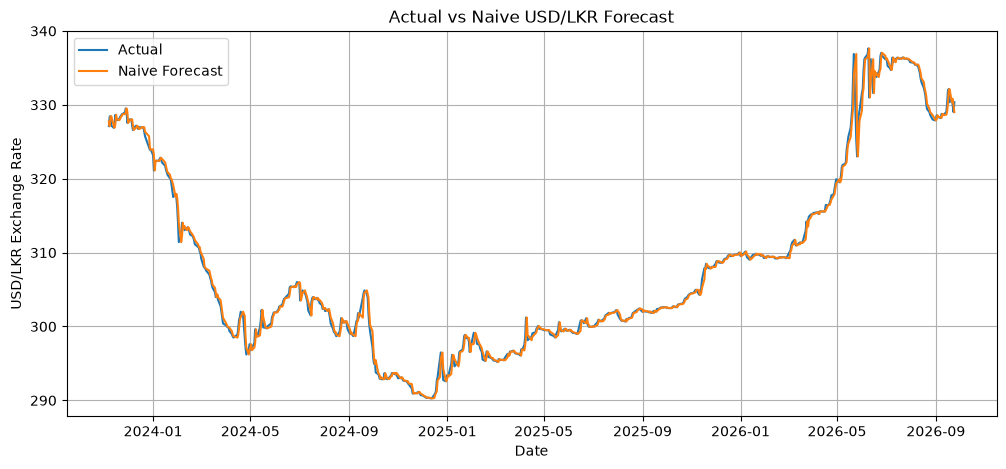

In [44]:
plt.figure(figsize=(12, 5))

plt.plot(
    test["date"],
    y_test,
    label="Actual"
)

plt.plot(
    test["date"],
    naive_predictions,
    label="Naive Forecast"
)

plt.title("Actual vs Naive USD/LKR Forecast")
plt.xlabel("Date")
plt.ylabel("USD/LKR Exchange Rate")
plt.legend()
plt.grid(True)

plt.show()

## 16. ARIMA Forecasting Model

ARIMA (AutoRegressive Integrated Moving Average) is used as a classical statistical time-series forecasting model.

The ARIMA model captures temporal dependence in the USD/LKR exchange-rate series through autoregressive, differencing, and moving-average components.

The model is trained using the historical training-period USD/LKR exchange-rate observations and is then used to generate forecasts for the testing period.

In [45]:
arima_train = train["USD_LKR"]

In [46]:
arima_model = ARIMA(
    arima_train,
    order=(1, 1, 1)
)

arima_result = arima_model.fit()

In [47]:
print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                USD_LKR   No. Observations:                 2781
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4667.342
Date:                Sun, 04 Oct 2026   AIC                           9340.683
Time:                        23:41:56   BIC                           9358.474
Sample:                             0   HQIC                          9347.107
                               - 2781                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8963      0.005    169.331      0.000       0.886       0.907
ma.L1         -0.7835      0.007   -112.240      0.000      -0.797      -0.770
sigma2         1.6818      0.005    320.088      0.0

## 18. Generate ARIMA Forecasts

The fitted ARIMA model is used to generate one-step-ahead forecasts across the testing period.

In [48]:
arima_predictions = arima_result.forecast(
    steps=len(test)
)

In [49]:
arima_mae = mean_absolute_error(
    y_test,
    arima_predictions
)

arima_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        arima_predictions
    )
)

print("ARIMA Model Performance")
print("-----------------------")
print("MAE :", arima_mae)
print("RMSE:", arima_rmse)

ARIMA Model Performance
-----------------------
MAE : 23.06353141166464
RMSE: 25.76817041378604


## 20. Actual vs ARIMA Forecast

The actual USD/LKR exchange rate is compared with the ARIMA forecasts over the testing period.

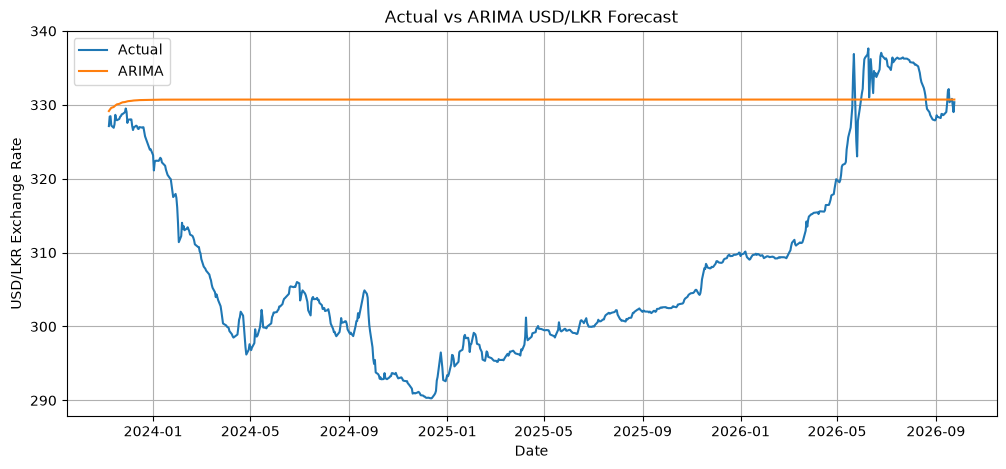

In [50]:
plt.figure(figsize=(12, 5))

plt.plot(
    test["date"],
    y_test,
    label="Actual"
)

plt.plot(
    test["date"],
    arima_predictions,
    label="ARIMA"
)

plt.title("Actual vs ARIMA USD/LKR Forecast")
plt.xlabel("Date")
plt.ylabel("USD/LKR Exchange Rate")
plt.legend()
plt.grid(True)

plt.show()

## 21. Initial Model Comparison

The naive baseline and ARIMA model are compared using MAE and RMSE.

Lower values indicate smaller forecasting errors.

In [51]:
results = pd.DataFrame({
    "Model": [
        "Naive",
        "ARIMA"
    ],
    "MAE": [
        naive_mae,
        arima_mae
    ],
    "RMSE": [
        naive_rmse,
        arima_rmse
    ]
})

results

,Model,MAE,RMSE
0,Naive,0.463135,0.886722
1,ARIMA,23.063531,25.768170


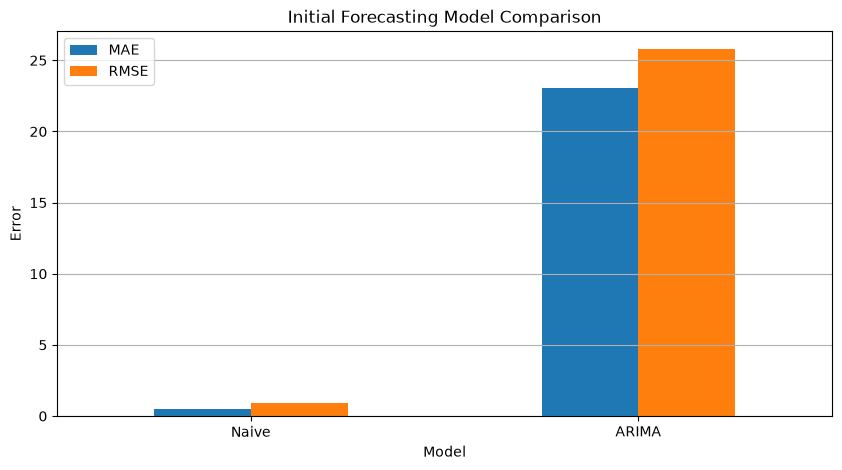

In [52]:
results.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Initial Forecasting Model Comparison")
plt.xlabel("Model")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

## 22. Save Initial Model Results

The performance results from the baseline and ARIMA models are stored in a results table.

Additional forecasting models will be added to this table during the modelling stage.

In [53]:
results.to_csv(
    "../data/processed/model_results_initial.csv",
    index=False
)

print("Initial model results saved successfully.")

Initial model results saved successfully.


# 23. GARCH Forecasting Model

The Generalized Autoregressive Conditional Heteroskedasticity (GARCH) model is used to model the time-varying volatility of USD/LKR exchange-rate returns.

Unlike ARIMA, which primarily models the temporal behaviour of the series, GARCH is designed to capture changes in conditional volatility.

For this project, the GARCH model is fitted to the daily logarithmic returns of the USD/LKR exchange rate.

The predicted return is subsequently converted into an exchange-rate forecast so that its forecasting performance can be compared with the other models.

In [54]:
%pip install arch

   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ---------------------- ----------------- 524.3/929.7 kB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 929.7/929.7 kB 3.8 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [55]:
from arch import arch_model

## 25. Prepare Data for GARCH

The GARCH model is fitted to the historical logarithmic returns rather than directly to the exchange-rate level.

The logarithmic return is used because GARCH models are designed to capture the conditional variance and volatility dynamics of financial returns.

In [56]:
garch_train_returns = train["log_return"].copy()

In [57]:
print("Number of GARCH training observations:", len(garch_train_returns))
print(garch_train_returns.head())

Number of GARCH training observations: 2781
0   -0.003326
1   -0.003742
2    0.000618
3    0.000898
4   -0.000757
Name: log_return, dtype: float64


## 26. Scale Logarithmic Returns

The logarithmic returns are multiplied by 100 before fitting the GARCH model.

This scaling does not change the underlying information in the returns. It improves numerical stability during model estimation.

In [58]:
garch_train_scaled = garch_train_returns * 100

## 27. Fit the GARCH(1,1) Model

A GARCH(1,1) model is fitted to the USD/LKR logarithmic returns.

The model contains:

- one lag of the conditional variance
- one lag of the squared return innovation

The GARCH(1,1) specification is commonly used as a starting point for modelling financial volatility.

In [59]:
garch_model = arch_model(
    garch_train_scaled,
    mean="AR",
    lags=1,
    vol="GARCH",
    p=1,
    q=1,
    dist="normal"
)

garch_result = garch_model.fit(
    disp="off"
)

In [60]:
print(garch_result.summary())

                           AR - GARCH Model Results                           
Dep. Variable:             log_return   R-squared:                      -0.211
Mean Model:                        AR   Adj. R-squared:                 -0.212
Vol Model:                      GARCH   Log-Likelihood:               -271.446
Distribution:                  Normal   AIC:                           552.891
Method:            Maximum Likelihood   BIC:                           582.542
                                        No. Observations:                 2780
Date:                Sun, Oct 04 2026   Df Residuals:                     2778
Time:                        23:47:44   Df Model:                            2
                                   Mean Model                                   
                    coef    std err          t      P>|t|       95.0% Conf. Int.
--------------------------------------------------------------------------------
Const         5.8905e-03  3.761e-03      1.566

## 28. Generate GARCH Return Forecasts

The fitted GARCH model is used to generate forecasts for the testing period.

The model produces forecasts for the conditional mean return and conditional variance.

The predicted mean return is used to construct the corresponding USD/LKR exchange-rate forecast.

In [61]:
garch_forecast = garch_result.forecast(
    horizon=len(test),
    reindex=False
)

In [62]:
garch_return_predictions = (
    garch_forecast.mean.iloc[-1].values / 100
)

In [63]:
print("Number of GARCH predictions:", len(garch_return_predictions))

Number of GARCH predictions: 696


## 29. Convert GARCH Return Forecasts to Exchange-Rate Forecasts

Because the GARCH model forecasts logarithmic returns, the predicted returns are transformed back into USD/LKR exchange-rate forecasts.

The transformation is:

Forecast USD/LKR(t+1)
=
USD/LKR(t) × exp(Forecast Log Return(t+1))

This allows the GARCH-based forecast to be evaluated against the actual USD/LKR exchange rate.

In [64]:
last_observed_rates = test["USD_LKR"].values

garch_predictions = (
    last_observed_rates *
    np.exp(garch_return_predictions)
)

In [65]:
print(garch_predictions[:10])

[327.70522863 327.12452966 328.42990279 328.49223446 327.23085202
 326.93583703 327.40860072 328.69081472 328.11989357 327.96358374]


## 30. Evaluate the GARCH Forecast

The GARCH-based exchange-rate forecasts are evaluated using MAE and RMSE.

Lower MAE and RMSE values indicate better forecasting accuracy.

In [66]:
garch_mae = mean_absolute_error(
    y_test,
    garch_predictions
)

garch_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        garch_predictions
    )
)

print("GARCH Model Performance")
print("-----------------------")
print("MAE :", garch_mae)
print("RMSE:", garch_rmse)

GARCH Model Performance
-----------------------
MAE : 0.46503861846087313
RMSE: 0.887715549939886


## 31. Actual vs GARCH Forecast

The actual USD/LKR exchange rate is compared with the GARCH-based exchange-rate forecast over the testing period.

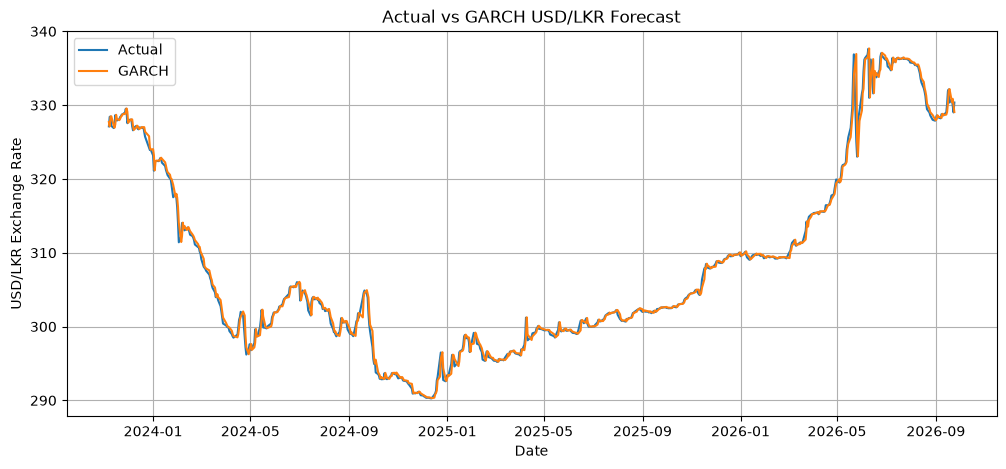

In [67]:
plt.figure(figsize=(12, 5))

plt.plot(
    test["date"],
    y_test,
    label="Actual"
)

plt.plot(
    test["date"],
    garch_predictions,
    label="GARCH"
)

plt.title("Actual vs GARCH USD/LKR Forecast")
plt.xlabel("Date")
plt.ylabel("USD/LKR Exchange Rate")
plt.legend()
plt.grid(True)

plt.show()

In [68]:
garch_result_row = pd.DataFrame({
    "Model": ["GARCH"],
    "MAE": [garch_mae],
    "RMSE": [garch_rmse]
})

results = pd.concat(
    [results, garch_result_row],
    ignore_index=True
)

results

,Model,MAE,RMSE
0,Naive,0.463135,0.886722
1,ARIMA,23.063531,25.768170
2,GARCH,0.465039,0.887716


## 33. Save Updated Model Results

The forecasting performance of the Naive, ARIMA, and GARCH models is stored for comparison with the machine-learning and deep-learning models developed later.

In [69]:
results.to_csv(
    "../data/processed/model_results.csv",
    index=False
)

print("Updated model results saved successfully.")

Updated model results saved successfully.


## 34. GARCH Conditional Volatility

The conditional volatility estimated by the GARCH model is examined to understand how the model captures changing exchange-rate risk over time.

Higher conditional volatility indicates periods of greater uncertainty in USD/LKR returns.

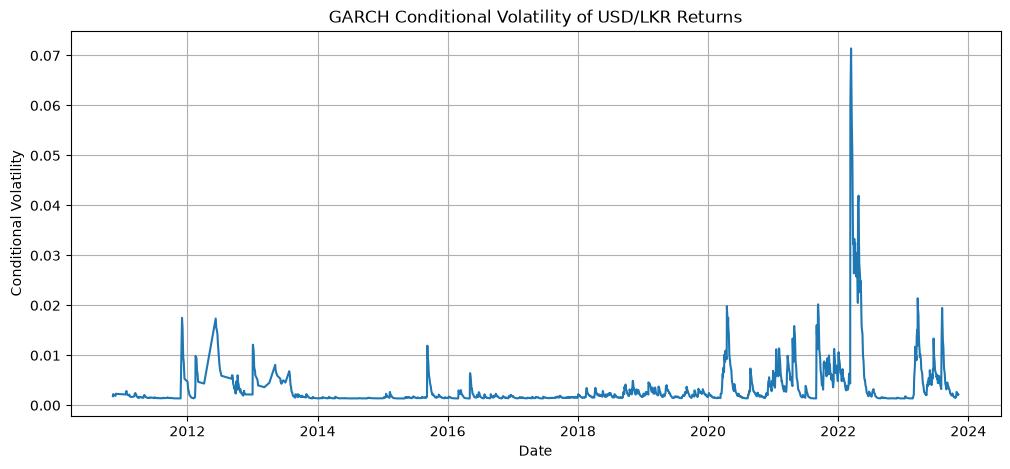

In [70]:
conditional_volatility = (
    garch_result.conditional_volatility / 100
)

plt.figure(figsize=(12, 5))

plt.plot(
    train["date"].iloc[-len(conditional_volatility):],
    conditional_volatility
)

plt.title("GARCH Conditional Volatility of USD/LKR Returns")
plt.xlabel("Date")
plt.ylabel("Conditional Volatility")
plt.grid(True)

plt.show()

In [71]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   - -------------------------------------- 1.3/48.9 MB 4.4 MB/s eta 0:00:11
   - -------------------------------------- 2.4/48.9 MB 4.9 MB/s eta 0:00:10
   -- ------------------------------------- 3.4/48.9 MB 5.0 MB/s eta 0:00:10
   --- ------------------------------------ 4.2/48.9 MB 4.8 MB/s eta 0:00:10
   ---- ----------------------------------- 5.2/48.9 MB 4.6 MB/s eta 0:00:10
   ---- ----------------------------------- 6.0/48.9 MB 4.6 MB/s eta 0:00:10
   ----- ---------------------------------- 6.8/48.9 MB 4.4 MB/s eta 0:00:10
   ------ --------------------------------- 7.9/48.9 MB 4.5 MB/s eta 0:00:10
   ------- -------------------------------- 8.7/48.9 MB 4.5 MB/s eta 0:00:09
   ------- -------------------------------- 9.7/48.9 MB 4.5 MB/s eta 0:00:09
   -------- ------------------------------- 10.5/48.9 MB 4.4 MB/s eta 0:00:09
   ---------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
from xgboost import XGBRegressor

# 36. XGBoost Forecasting Model

XGBoost (Extreme Gradient Boosting) is used as a machine-learning forecasting model.

Unlike ARIMA and GARCH, XGBoost can directly use the engineered predictor variables created in the previous feature-engineering stage.

The model uses historical exchange-rate values, lagged returns, rolling statistics, and volatility-related features to predict the next USD/LKR exchange rate.

The chronological train-test split established earlier is retained to prevent future information from entering the training process.

In [73]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

## 37. Train the XGBoost Model

The XGBoost regressor is trained using the feature-engineered training dataset.

Only observations from the training period are used during model fitting.

In [74]:
xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## 38. Generate XGBoost Forecasts

The trained XGBoost model is used to predict the USD/LKR exchange rate for the unseen testing period.

In [75]:
xgb_predictions = xgb_model.predict(
    X_test
)

In [76]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

print("XGBoost Model Performance")
print("-------------------------")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)

XGBoost Model Performance
-------------------------
MAE : 1.8576607608488238
RMSE: 2.4265692720228578


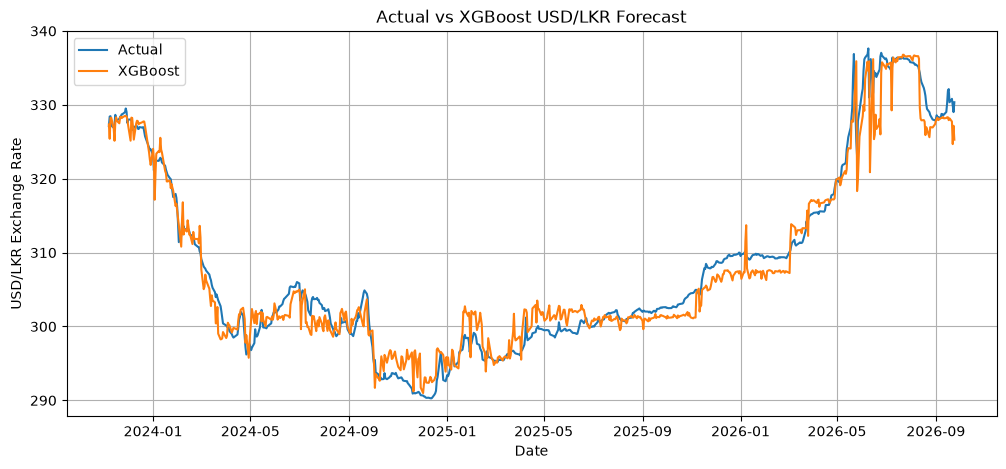

In [77]:
plt.figure(figsize=(12, 5))

plt.plot(
    test["date"],
    y_test,
    label="Actual"
)

plt.plot(
    test["date"],
    xgb_predictions,
    label="XGBoost"
)

plt.title("Actual vs XGBoost USD/LKR Forecast")
plt.xlabel("Date")
plt.ylabel("USD/LKR Exchange Rate")
plt.legend()
plt.grid(True)

plt.show()

In [78]:
xgb_result_row = pd.DataFrame({
    "Model": ["XGBoost"],
    "MAE": [xgb_mae],
    "RMSE": [xgb_rmse]
})

results = pd.concat(
    [results, xgb_result_row],
    ignore_index=True
)

results

,Model,MAE,RMSE
0,Naive,0.463135,0.886722
1,ARIMA,23.063531,25.768170
2,GARCH,0.465039,0.887716
3,XGBoost,1.857661,2.426569


# 44. LSTM Forecasting Model

Long Short-Term Memory (LSTM) is a recurrent neural-network architecture designed to learn sequential and temporal patterns.

LSTM is included in this project to evaluate whether a deep-learning approach can improve USD/LKR exchange-rate forecasting compared with the statistical and machine-learning models.

The LSTM model uses historical observations arranged into sequential windows. Each sequence contains information from previous observations and is used to predict the next USD/LKR exchange rate.

The chronological train-test split is maintained to avoid using future observations during model training.

## 45. Import LSTM Libraries

The TensorFlow and Keras libraries are used to construct and train the LSTM forecasting model.

In [81]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from sklearn.preprocessing import MinMaxScaler

In [80]:
%pip install tensorflow

  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 930.4 kB/s eta 0:06:17
   ---------------------------------------- 0.5/351.2 MB 930.4 kB/s eta 0:06:17
   ---------------------------------------- 1.0/351.2 MB 1.1 MB/s eta 0:05:12
   ---------------------------------------- 1.3/351.2 MB 1.1 MB/s eta 0:05:06
   ---------------------------------------- 1.6/351.2 MB 1.2 MB/s eta 0:04:48
   ---------------------------------------- 1.8/351.2 MB 1.2 MB/s eta 0:04:52
   ---------------------------------------- 2.1/351.2 MB 1.2 MB/s eta 0:04:43
   ---------------------------------------- 2.4/351.2 MB 1.2 MB/s eta 0:04:43
   ---------------------------------------- 2.6/351.2 MB 1.3 MB/s eta 0:04:34
   ----------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 46. Prepare Data for LSTM

The LSTM model requires sequential input data.

The USD/LKR exchange-rate series is therefore separated into training and testing periods using the same chronological split used for the previous forecasting models.

Only historical information available before the prediction point is used to construct each input sequence.

In [82]:
lstm_series = df["USD_LKR"].values.reshape(-1, 1)

split_index = int(len(lstm_series) * 0.80)

train_series = lstm_series[:split_index]
test_series = lstm_series[split_index:]

In [83]:
print("Training observations:", len(train_series))
print("Testing observations:", len(test_series))

Training observations: 2781
Testing observations: 696


## 47. Scale the USD/LKR Series

LSTM neural networks generally perform better when numerical inputs are scaled to a small range.

Min-Max scaling is applied using only the training data.

The scaler is fitted on the training observations and then used to transform both training and testing observations. This prevents information from the future testing period from influencing the scaling process.

In [84]:
lstm_scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = lstm_scaler.fit_transform(train_series)
test_scaled = lstm_scaler.transform(test_series)

## 48. Create Sequential Input Windows

A look-back window of 20 observations is used.

For each prediction:

- the previous 20 USD/LKR observations are provided as input;
- the following observation is used as the target.

This converts the time series into the three-dimensional structure required by an LSTM model:

(samples, time steps, features)

In [85]:
lookback = 20

X_lstm_train = []
y_lstm_train = []

for i in range(lookback, len(train_scaled)):
    X_lstm_train.append(
        train_scaled[i-lookback:i, 0]
    )
    y_lstm_train.append(
        train_scaled[i, 0]
    )

X_lstm_train = np.array(X_lstm_train)
y_lstm_train = np.array(y_lstm_train)

X_lstm_train = X_lstm_train.reshape(
    X_lstm_train.shape[0],
    X_lstm_train.shape[1],
    1
)

print("LSTM training input shape:", X_lstm_train.shape)
print("LSTM training target shape:", y_lstm_train.shape)

LSTM training input shape: (2761, 20, 1)
LSTM training target shape: (2761,)


## 49. Create Testing Sequences

The testing sequences are constructed using the final observations from the training period together with the testing observations.

The previous 20 observations are required to make the first prediction in the testing period.

In [86]:
combined_series = np.concatenate(
    [train_scaled[-lookback:], test_scaled]
)

X_lstm_test = []
y_lstm_test = []

for i in range(lookback, len(combined_series)):
    X_lstm_test.append(
        combined_series[i-lookback:i, 0]
    )
    y_lstm_test.append(
        combined_series[i, 0]
    )

X_lstm_test = np.array(X_lstm_test)
y_lstm_test = np.array(y_lstm_test)

X_lstm_test = X_lstm_test.reshape(
    X_lstm_test.shape[0],
    X_lstm_test.shape[1],
    1
)

print("LSTM testing input shape:", X_lstm_test.shape)
print("LSTM testing target shape:", y_lstm_test.shape)

LSTM testing input shape: (696, 20, 1)
LSTM testing target shape: (696,)


## 50. Build the LSTM Architecture

A two-layer LSTM architecture is used for the forecasting task.

The first LSTM layer learns temporal patterns from the input sequences.

The second LSTM layer further processes the learned sequential representation.

Dropout layers are included to reduce the risk of overfitting.

The final Dense layer produces the predicted USD/LKR exchange-rate value.

In [87]:
lstm_model = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(lookback, 1)
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

## 51. Train the LSTM Model

The LSTM model is trained using the historical training sequences.

A validation split is used to monitor the model's learning performance during training.

The model does not use the testing observations during training.

In [88]:
history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    verbose=1
)

Epoch 1/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0026 - val_loss: 0.0243
Epoch 2/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0054 - val_loss: 0.0476
Epoch 3/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0038 - val_loss: 0.0122
Epoch 4/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0013 - val_loss: 0.0022
Epoch 5/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0019 - val_loss: 0.0387
Epoch 6/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0037 - val_loss: 0.0125
Epoch 7/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0027 - val_loss: 0.0250
Epoch 8/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0039 - val_loss: 0.0165
Epoch 9/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0015 - val_loss: 0.0112
Epoch 10/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0015 - val_loss: 0.0065
Epoch 11/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0032 - val_loss: 0.0093
Epoch 12/30
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0057 - val_

## 52. LSTM Training and Validation Loss

The training and validation loss are plotted to examine how the LSTM model learned during training and to identify possible signs of overfitting.

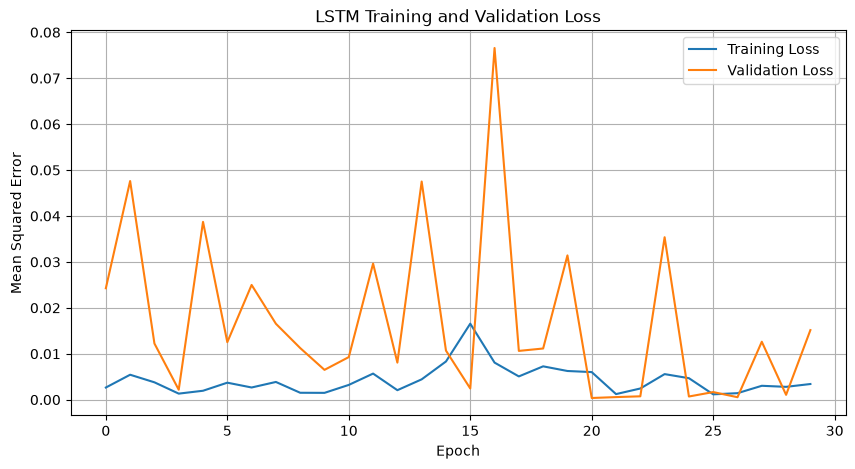

In [89]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)

plt.show()

## 53. Generate LSTM Forecasts

The trained LSTM model is applied to the unseen testing sequences to generate exchange-rate predictions.

In [90]:
lstm_predictions_scaled = lstm_model.predict(
    X_lstm_test,
    verbose=0
)

## 54. Inverse Transform LSTM Predictions

The LSTM predictions are initially expressed in the scaled range.

The fitted Min-Max scaler is therefore used to transform the predictions back to their original USD/LKR exchange-rate scale.

In [91]:
lstm_predictions = lstm_scaler.inverse_transform(
    lstm_predictions_scaled
).flatten()

lstm_actual = lstm_scaler.inverse_transform(
    y_lstm_test.reshape(-1, 1)
).flatten()

## 55. Evaluate LSTM Forecast Performance

The LSTM model is evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

These metrics are consistent with the evaluation used for the Naive, ARIMA, GARCH, and XGBoost models.

In [92]:
lstm_mae = mean_absolute_error(
    lstm_actual,
    lstm_predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        lstm_actual,
        lstm_predictions
    )
)

print("LSTM Model Performance")
print("----------------------")
print("MAE :", lstm_mae)
print("RMSE:", lstm_rmse)

LSTM Model Performance
----------------------
MAE : 21.718804172489563
RMSE: 22.096873495654336


## 56. Actual vs LSTM Forecast

The actual USD/LKR exchange rate is compared with the LSTM predictions over the testing period.

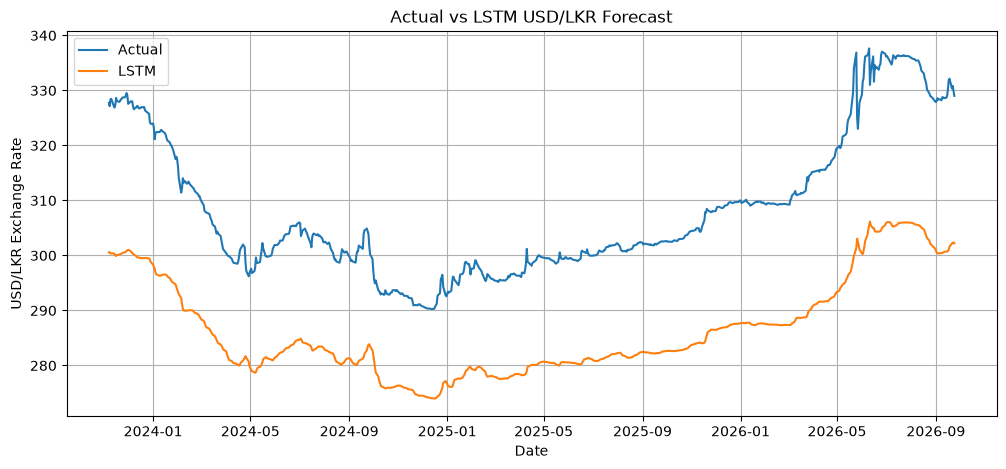

In [93]:
lstm_test_dates = test["date"].iloc[:len(lstm_predictions)]

plt.figure(figsize=(12, 5))

plt.plot(
    lstm_test_dates,
    lstm_actual,
    label="Actual"
)

plt.plot(
    lstm_test_dates,
    lstm_predictions,
    label="LSTM"
)

plt.title("Actual vs LSTM USD/LKR Forecast")
plt.xlabel("Date")
plt.ylabel("USD/LKR Exchange Rate")
plt.legend()
plt.grid(True)

plt.show()

## 57. Add LSTM to the Model Comparison

The LSTM forecasting performance is added to the existing model-results table.

The final comparison will contain five forecasting approaches:

- Naive
- ARIMA
- GARCH
- XGBoost
- LSTM

In [94]:
lstm_result_row = pd.DataFrame({
    "Model": ["LSTM"],
    "MAE": [lstm_mae],
    "RMSE": [lstm_rmse]
})

results = pd.concat(
    [results, lstm_result_row],
    ignore_index=True
)

results

,Model,MAE,RMSE
0,Naive,0.463135,0.886722
1,ARIMA,23.063531,25.768170
2,GARCH,0.465039,0.887716
3,XGBoost,1.857661,2.426569
4,LSTM,21.718804,22.096873


In [95]:
results.to_csv(
    "../data/processed/model_results.csv",
    index=False
)

print("Complete model results saved successfully.")

Complete model results saved successfully.


# 59. Final Model Comparison

The forecasting performance of all developed models is compared using MAE and RMSE.

The models evaluated are:

1. Naive
2. ARIMA
3. GARCH
4. XGBoost
5. LSTM

Lower MAE and RMSE values indicate better forecasting accuracy.

The final model selection is based on out-of-sample performance on the chronological testing period.

In [96]:
results.sort_values(
    by="RMSE",
    ascending=True
)

,Model,MAE,RMSE
0,Naive,0.463135,0.886722
2,GARCH,0.465039,0.887716
3,XGBoost,1.857661,2.426569
4,LSTM,21.718804,22.096873
1,ARIMA,23.063531,25.768170


## 60. Select the Best Forecasting Model

The model with the lowest RMSE on the testing dataset is identified as the best-performing forecasting model.

MAE is also considered as a secondary measure of forecasting accuracy.

In [97]:
best_model = results.loc[
    results["RMSE"].idxmin()
]

print("Best Model:")
print(best_model)

Best Model:
Model       Naive
MAE      0.463135
RMSE     0.886722
Name: 0, dtype: object


In [98]:
best_mae_model = results.loc[
    results["MAE"].idxmin()
]

print("Best Model by MAE:")
print(best_mae_model)

Best Model by MAE:
Model       Naive
MAE      0.463135
RMSE     0.886722
Name: 0, dtype: object


## 61. Model Performance Comparison

The MAE and RMSE values of the five forecasting models are visualized to facilitate direct comparison.

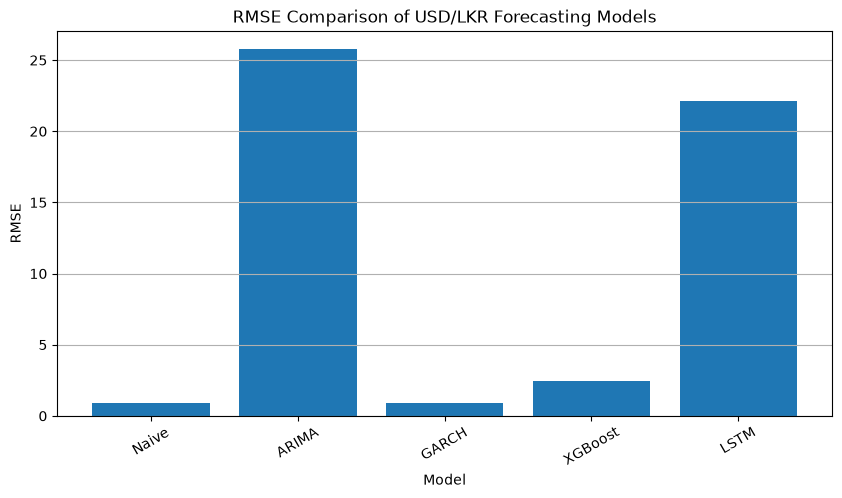

In [99]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title("RMSE Comparison of USD/LKR Forecasting Models")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.grid(axis="y")

plt.show()

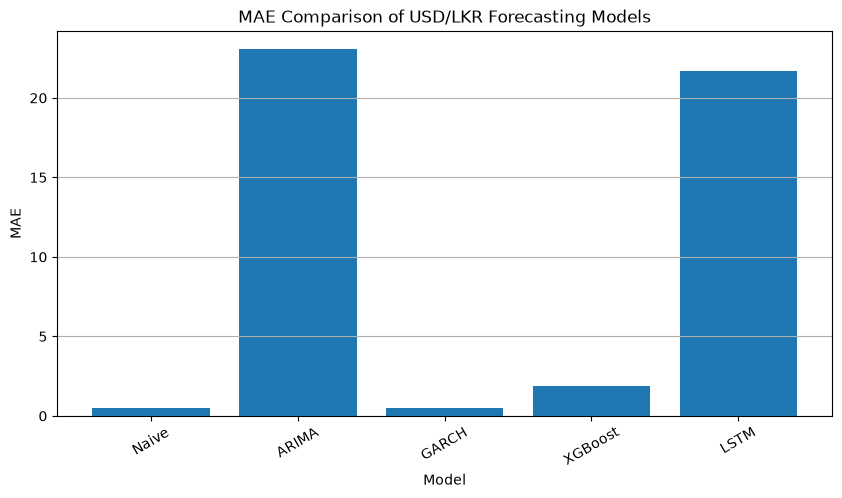

In [100]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["MAE"]
)

plt.title("MAE Comparison of USD/LKR Forecasting Models")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=30)
plt.grid(axis="y")

plt.show()

# 62. Final Forecasting Summary

The project evaluated five approaches for one-step-ahead USD/LKR exchange-rate forecasting:

- Naive forecasting
- ARIMA
- GARCH
- XGBoost
- LSTM

The models were evaluated using a chronological train-test split to preserve the temporal structure of the exchange-rate data.

MAE and RMSE were used as the primary forecasting evaluation metrics.

The final model was selected based on its out-of-sample forecasting performance rather than model complexity.

The results demonstrate whether statistical, volatility-based, machine-learning, or deep-learning approaches provide the most accurate forecasts for the USD/LKR exchange-rate series.

In [101]:
results.to_csv(
    "../data/processed/final_model_results.csv",
    index=False
)

print("Final model results saved successfully.")

Final model results saved successfully.


# 63. Overall Forecasting Analysis and Conclusion

## Overall Analysis

This project developed and evaluated a forecasting framework for the historical USD/LKR exchange-rate series.

The analysis followed a sequential workflow consisting of data collection, exploratory data analysis, statistical analysis, feature engineering, and forecasting-model development.

The exploratory and statistical analysis examined the historical behaviour of the exchange-rate series, daily logarithmic returns, rolling volatility, the 2022 crisis period, return distributions, stationarity using the Augmented Dickey-Fuller test, and temporal dependence using ACF and PACF analysis.

The feature-engineering stage transformed the historical exchange-rate data into modelling-ready variables. These included exchange-rate lag features, lagged return features, and rolling statistical features. A one-step-ahead forecasting target was also created by shifting the USD/LKR exchange-rate series by one observation.

Five forecasting approaches were evaluated:

1. Naive Forecasting
2. ARIMA
3. GARCH
4. XGBoost
5. LSTM

The models were evaluated using a chronological train-test split to preserve the temporal structure of the data. Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) were used as the primary evaluation metrics.

## Final Model Performance

| Model | MAE | RMSE |
|---|---:|---:|
| Naive | 0.463135 | 0.886722 |
| GARCH | 0.465039 | 0.887716 |
| XGBoost | 1.857661 | 2.426569 |
| LSTM | 21.718804 | 22.096873 |
| ARIMA | 23.063531 | 25.768170 |

Lower MAE and RMSE values indicate better forecasting performance.

## Final Model Selection

Based on the out-of-sample testing results, the Naive forecasting model achieved the lowest MAE and RMSE among the evaluated models.

The Naive model obtained:

- **MAE:** 0.463135
- **RMSE:** 0.886722

Therefore, the Naive model is selected as the best-performing forecasting approach for the evaluated USD/LKR exchange-rate forecasting task.

Interestingly, the GARCH model produced very similar performance, with an MAE of 0.465039 and an RMSE of 0.887716. This indicates that its forecasting accuracy was very close to the Naive benchmark.

The XGBoost model performed less accurately than the Naive and GARCH approaches based on both evaluation metrics.

The LSTM and ARIMA models produced substantially higher MAE and RMSE values on the testing period and therefore did not outperform the simpler forecasting approaches in this experiment.

## Overall Conclusion

The results demonstrate that increased model complexity does not necessarily lead to improved forecasting accuracy for the evaluated USD/LKR exchange-rate series.

Although ARIMA, GARCH, XGBoost, and LSTM provide increasingly sophisticated modelling approaches, the simple Naive benchmark achieved the strongest out-of-sample performance in this study.

This finding highlights the importance of establishing strong baseline models and evaluating more complex approaches against them using consistent time-based testing.

The final results provide a data-driven comparison of statistical, volatility-based, machine-learning, and deep-learning approaches for USD/LKR exchange-rate forecasting.

Future work could investigate alternative feature-engineering strategies, different model configurations, hyperparameter optimization, additional exogenous economic variables, and more advanced time-series validation strategies to determine whether more complex models can consistently outperform the Naive benchmark.

# 64. Final Forecast Using the Selected Model

Based on the out-of-sample evaluation, the Naive forecasting model achieved the lowest MAE and RMSE.

Therefore, the Naive model is selected as the final forecasting approach.

The final forecast represents the one-step-ahead USD/LKR exchange-rate prediction based on the most recent available observation.

In [102]:
# Latest observed USD/LKR exchange rate
latest_usd_lkr = df["USD_LKR"].iloc[-1]

# Naive one-step-ahead forecast
final_forecast = latest_usd_lkr

print("Latest observed USD/LKR:", latest_usd_lkr)
print("Final one-step-ahead forecast:", final_forecast)

Latest observed USD/LKR: 329.0158
Final one-step-ahead forecast: 329.0158


# 65. Save the Final Forecast

The selected model and its final one-step-ahead forecast are saved for documentation and future use.

In [103]:
final_forecast_output = pd.DataFrame({
    "Selected_Model": ["Naive"],
    "Latest_Observed_USD_LKR": [latest_usd_lkr],
    "Forecast_Horizon": ["One-Step-Ahead"],
    "Forecast_USD_LKR": [final_forecast]
})

final_forecast_output.to_csv(
    "../data/processed/final_forecast.csv",
    index=False
)

final_forecast_output

,Selected_Model,Latest_Observed_USD_LKR,Forecast_Horizon,Forecast_USD_LKR
0,Naive,329.0158,One-Step-Ahead,329.0158


# 66. Final Results Table

The final results provide a consolidated summary of the forecasting models evaluated in this study and their out-of-sample performance.

In [104]:
final_results = results.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

final_results

,Model,MAE,RMSE
0,Naive,0.463135,0.886722
1,GARCH,0.465039,0.887716
2,XGBoost,1.857661,2.426569
3,LSTM,21.718804,22.096873
4,ARIMA,23.063531,25.768170


In [105]:
final_results.to_csv(
    "../data/processed/final_model_comparison.csv",
    index=False
)

print("Final model comparison saved successfully.")

Final model comparison saved successfully.


# 67. Overall Forecasting Conclusion

The forecasting stage evaluated five approaches for one-step-ahead USD/LKR exchange-rate prediction: Naive, ARIMA, GARCH, XGBoost, and LSTM.

The models were evaluated using out-of-sample testing data with Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

Among the evaluated approaches, the Naive model achieved the lowest MAE of 0.463135 and the lowest RMSE of 0.886722. Therefore, the Naive model was identified as the best-performing model for the selected testing period.

GARCH produced very similar performance, with an MAE of 0.465039 and RMSE of 0.887716. XGBoost achieved higher forecasting errors, while LSTM and ARIMA produced substantially larger errors on the testing period.

The results demonstrate that model complexity did not necessarily result in better forecasting accuracy for this dataset and evaluation period. The simple Naive benchmark provided the most accurate out-of-sample forecasts among the models evaluated.

The final selected model and model-comparison results have been saved for further reporting and analysis.